# Objectieve 1

# To assess the Stationarity of Fish Export Price

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
frozenfish = {'Year': ['1995-96','1996-97','1997-98','1998-99','1999-00','2000-01','2001-02','2002-03','2003-04','2004-05','2005-06','2006-07','2007-08','2008-09','2009-10','2010-11','2011-12','2012-13','2013-14','2014-15','2015-16','2016-17','2017-18','2018-19','2019-20','2020-21',
'2021-22',"2022-23"],'Quantity': [100093,173005,188029,108556,131304,212903,174976,196322,138023,159689,182344,270751,220200,238544,260979,312358,347118,343876,324359,309434,228749,296762,353192,338933,223318,188130,226586,368549],
        'Price': [372.26,636.92,726.73,495.03,537.34,874.68,713.11,841.65,620.73,759.27,998.7,1452.88,1303.41,1722.34,2032.33,2623.89,3284.15,3296.86,4294.81,3778.5,3462.25,4460.9,4674.03,4916.82,3610.01,2941.65,3471.91,5503.1]}
df2=pd.DataFrame(frozenfish)

In [ ]:
# H0 : The given time series is non-stationary
# H1 : The given time series is stationary

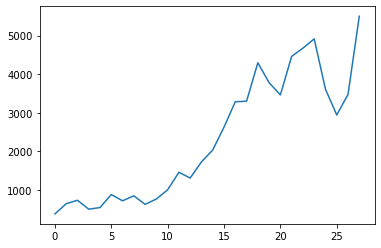

In [3]:
plt.plot(df2['Price'])

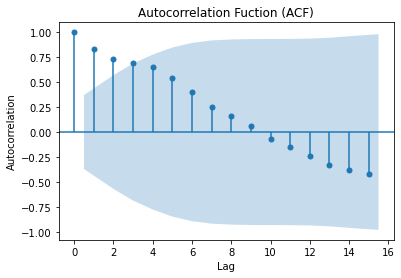

In [7]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
values = df2['Price'].values

#plot  the ACF
plot_acf(values)
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.title('Autocorrelation Fuction (ACF)')
plt.show()

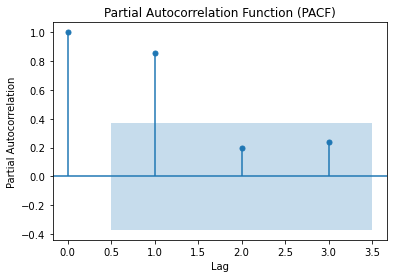

In [8]:
# Plot the PACF
plot_pacf(values,lags=3)
plt.xlabel('Lag')
plt.ylabel('Partial Autocorrelation')
plt.title('Partial Autocorrelation Function (PACF)')
plt.show()

In [9]:
# to check the stationarity use ADF test
from statsmodels.tsa.stattools import adfuller
price_column = df2["Price"]
result=adfuller(price_column)
adf_statistics = result[0]
p_value = result[1]
print(f'ADF Statistics: {adf_statistics}')
print(f'p_value: {p_value}')

ADF Statistics: -1.4784972509943066
p_value: 0.5441203622396066


# Objectieve 2

# To find the cointegration relation between Fish Export Price and Quantity

In [5]:
import pandas as pd
import numpy as np
import statsmodels.api as sm


# Extract the two variables
variable1 = df2['Quantity']
variable2 = df2['Price']

# Step 1: Perform ADF test to check for unit roots

# Augmented Dickey-Fuller test on variable 1
adf_result1 = sm.tsa.stattools.adfuller(variable1)
adf_stat1 = adf_result1[0]
p_value1 = adf_result1[1]
critical_values1 = adf_result1[4]

# Augmented Dickey-Fuller test on variable 2
adf_result2 = sm.tsa.stattools.adfuller(variable2)
adf_stat2 = adf_result2[0]
p_value2 = adf_result2[1]
critical_values2 = adf_result2[4]

# Check if variables are stationary (reject null hypothesis of unit root)
print(f'p_value1: {p_value1}')
print(f'p_value2: {p_value2}')

if p_value1 < 0.05 and p_value2 < 0.05:
    print("Variables are not stationary. Cannot proceed with Engel-Granger Two-Step procedure.")
else:    
    print("Variables are stationary. Proceeding to Step 2.")


p_value1: 0.4532066144242554
p_value2: 0.5441203622396066
Variables are stationary. Proceeding to Step 2.


In [9]:
#Step 2: Estimate the cointegrating relationship using OLS

# Add a constant column to the independent variable
Quantity_with_constant = sm.add_constant(df2['Quantity'])

# Fit the OLS model
model = sm.OLS(df2['Price'], Quantity_with_constant)
result = model.fit()

# Get the estimated coefficients
intercept = result.params[0]
slope = result.params[1]

# Print the results
print("Cointegrating Relationship:")
print("Price = {} + {} * Quantity".format(intercept, slope))
print("\nOLS Summary:")
print(result.summary())
print(model)

Cointegrating Relationship:
Price = -1798.9014764479912 + 0.017345334596207778 * Quantity

OLS Summary:
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.713
Model:                            OLS   Adj. R-squared:                  0.702
Method:                 Least Squares   F-statistic:                     64.48
Date:                Sun, 16 Jul 2023   Prob (F-statistic):           1.65e-08
Time:                        13:14:03   Log-Likelihood:                -228.81
No. Observations:                  28   AIC:                             461.6
Df Residuals:                      26   BIC:                             464.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------

# 3rd 

# vector Error correction model

In [13]:
import pandas as pd
import numpy as np
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM

# Extract the variables
variables = df2[[ 'Quantity','Price']]

# Perform Johansen cointegration test
coint_result = coint_johansen(variables, det_order=-1, k_ar_diff=1)

# Extract the cointegrating vectors
coint_vectors = coint_result.evec

# Specify the number of cointegrating vectors to use for prediction
num_coint_vectors = 1

# Create the VECM model using the cointegrating vectors
model = VECM(variables, k_ar_diff=1, coint_rank=num_coint_vectors, deterministic='nc')
model_fit = model.fit()
parameters = model_fit.params
print("Parameter Estimates:")
print(parameters)
print("\n")
print(model)
# Generate predictions for the next 'n' steps
n = 10
forecast = model_fit.predict(steps=10)

# Print the forecasted values
print("Forecasted Values:")
print(forecast)


AttributeError: 'VECMResults' object has no attribute 'params'

# VAR MODEL

In [76]:
import pandas as pd
import numpy as np
from statsmodels.tsa.api import VAR

# Extract the variables of interest
variables = df2[['Quantity', 'Price']] 

# Create a VAR model with a specified lag order (p)
model = VAR(variables)
results = model.fit(maxlags=2) 
print(model)
parameters = results.params
print("Parameter Estimates:")
print(parameters)
print("\n")
# Print the estimated coefficients
print("Estimated Coefficients:")
print(results.coefs)


# Forecast future values
n_periods = 10  # Number of periods to forecast
forecast = results.forecast(variables.values[-2:], steps=n_periods)  # Specify the appropriate lag order

# Print the forecasted values
print("Forecasted Values:")
print(forecast)



Parameter Estimates:
                  Quantity       Price
const        148308.225741  831.866983
L1.Quantity       0.137446   -0.002084
L1.Price         83.201867    1.305815
L2.Quantity      -0.017721   -0.002078
L2.Price        -56.290948   -0.168420


Estimated Coefficients:
[[[ 1.37446226e-01  8.32018671e+01]
  [-2.08382660e-03  1.30581481e+00]]

 [[-1.77205597e-02 -5.62909485e+01]
  [-2.07806300e-03 -1.68419614e-01]]]
Forecasted Values:
[[457379.75227486   6194.30654502]
 [410245.60360355   6274.68611262]
 [369972.12017752   6176.85769647]
 [352607.77637396   6217.445092  ]
 [359818.58293441   6406.7960555 ]
 [374587.03768977   6668.27576477]
 [387585.98122965   6932.07001703]
 [396340.16516098   7174.72082375]
 [402652.81766613   7401.89489043]
 [408607.60134046   7626.32877764]]


In [26]:
#VARMAX

In [ ]:
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.varmax import VARMAX
model = VARMAX(data, order=(p, d, q))
results = model.fit()
forecast = results.forecast(steps)


In [63]:
import pandas as pd
import numpy as np
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM

# Extract the variables
variables = df2[[ 'Quantity','Price']]

# Perform Johansen cointegration test
coint_result = coint_johansen(variables, det_order=-1, k_ar_diff=1)

# Extract the cointegrating vectors
coint_vectors = coint_result.evec

# Specify the number of cointegrating vectors to use for prediction
num_coint_vectors = 1

# Create the VECM model using the cointegrating vectors
model = VECM(variables, k_ar_diff=1, coint_rank=num_coint_vectors, deterministic='nc')
model_fit = model.fit()
print(model_fit)
# Generate predictions for the next 'n' steps
n = 10
forecast = model_fit.predict(steps=10)

# Print the forecasted values
print("Forecasted Values:")
print(forecast)
model_fit.predict(10, 0.05)

Forecasted Values:
[[412749.52820423   5943.3476698 ]
 [415394.53304396   6219.80242841]
 [420930.15131201   6452.69011596]
 [424070.71656987   6685.35712824]
 [427756.25296408   6915.60641197]
 [431230.1149453    7145.7852915 ]
 [434758.4631583    7375.38200854]
 [438260.23758634   7604.59369843]
 [441761.75819644   7833.36341583]
 [445254.73962707   8061.71100173]]


In [71]:
model_fit.predict(10, 0.05)

(array([[412749.52820423,   5943.3476698 ],
        [415394.53304396,   6219.80242841],
        [420930.15131201,   6452.69011596],
        [424070.71656987,   6685.35712824],
        [427756.25296408,   6915.60641197],
        [431230.1149453 ,   7145.7852915 ],
        [434758.4631583 ,   7375.38200854],
        [438260.23758634,   7604.59369843],
        [441761.75819644,   7833.36341583],
        [445254.73962707,   8061.71100173]]),
 array([[302783.40708381,   4735.71805979],
        [247774.28959447,   4359.74226296],
        [209115.35816098,   4054.20838395],
        [174943.78077331,   3808.46621297],
        [145655.56959929,   3592.68702183],
        [119105.11987177,   3396.4752844 ],
        [ 94781.79403086,   3211.79135693],
        [ 72103.56635411,   3034.26711339],
        [ 50758.55418959,   2860.80320907],
        [ 30495.8600945 ,   2689.32039706]]),
 array([[522715.64932465,   7150.97727981],
        [583014.77649345,   8079.86259387],
        [632744.94446304,   